In [1]:
# %pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
import seaborn as sns
sns.set()

In [3]:
# load data set 
df = pd.read_csv("Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
print(df.columns.to_list())

['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [5]:
print(df.shape)

(255347, 18)


In [6]:
df.drop("LoanID",axis=1,inplace=True)

In [7]:
binary_col = ["HasMortgage","HasDependents","HasCoSigner"]
for col in binary_col:
    df[col] = df[col].map({"Yes":1,"No":0})

In [8]:
categorical_cols = ["Education","EmploymentType","MaritalStatus","LoanPurpose"]
for col in categorical_cols:
    df[col] = df[col].astype("category").cat.codes

df.head()    

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


In [9]:
print(df.isnull().sum())

Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [10]:
X = df.drop("Default",axis=1)
y = df['Default']

In [11]:
# traning data 75% testing 25%
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.25,random_state=42) 

In [12]:
# using random forest model 
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

print("Accuracy ",accuracy_score(y_test,rf_pred))
print("Classification Report ",classification_report(y_test,rf_pred))

Accuracy  0.8859908830302176
Classification Report                precision    recall  f1-score   support

           0       0.89      1.00      0.94     56410
           1       0.64      0.05      0.09      7427

    accuracy                           0.89     63837
   macro avg       0.76      0.52      0.51     63837
weighted avg       0.86      0.89      0.84     63837



In [16]:
# XGboost Model
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42,
    eval_metric="logloss" 
)

xgb.fit(X_train,y_train)
xgb_pred = xgb.predict(X_test)

print("accuracy : - ",accuracy_score(y_test,xgb_pred))
print("Classification Report : - ",classification_report(y_test,xgb_pred))

accuracy : -  0.8871657502702195
Classification Report : -                precision    recall  f1-score   support

           0       0.89      0.99      0.94     56410
           1       0.63      0.07      0.13      7427

    accuracy                           0.89     63837
   macro avg       0.76      0.53      0.53     63837
weighted avg       0.86      0.89      0.85     63837



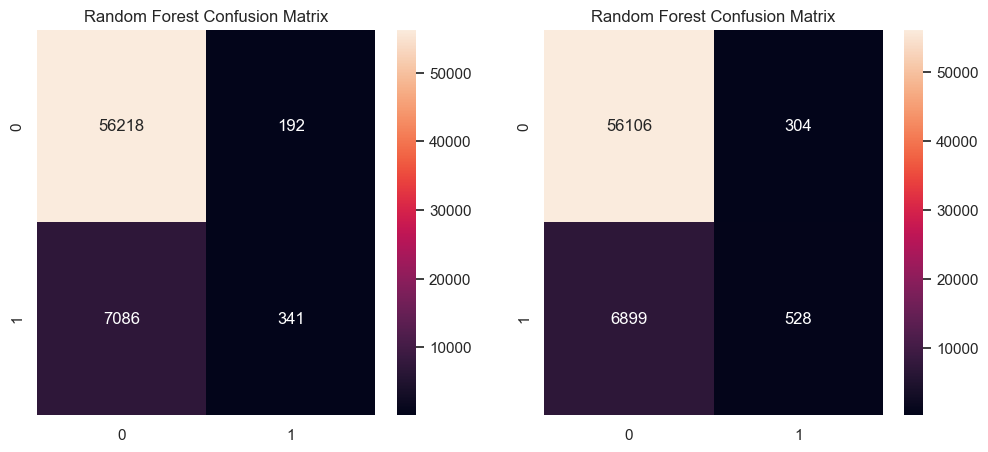

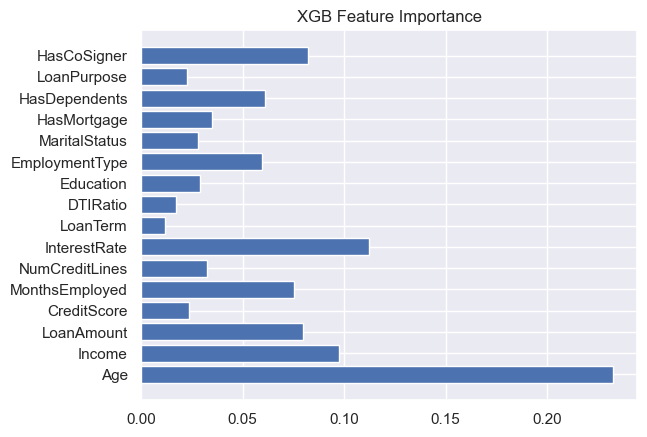

In [20]:
# confusion Matrices

fig , ax = plt.subplots(1,2,figsize=(12,5))
sns.heatmap(confusion_matrix(y_test,rf_pred),annot=True,fmt="d",ax=ax[0])
ax[0].set_title("Random Forest Confusion Matrix")

sns.heatmap(confusion_matrix(y_test,xgb_pred),annot=True,fmt="d",ax=ax[1])
ax[1].set_title("Random Forest Confusion Matrix")

plt.show()

importance = xgb.feature_importances_
plt.barh(X.columns,importance)
plt.title("XGB Feature Importance")
plt.show()